# 🛒 E-Commerce Sales Prediction — MIS444 Course Project
**Dataset:** Amazon E-Commerce Sales Data (Kaggle)  
**Target Variable:** `Amount` (Order Revenue)  
**Problem Type:** Regression  
**Author:** [Your Name] | **Course:** MIS444 — Predictive Analytics in Business


## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               AdaBoostRegressor, ExtraTreesRegressor, StackingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Consistent style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
print("All libraries imported successfully ✅")

All libraries imported successfully ✅


## 2. Data Collection
The dataset is sourced from [Kaggle — Unlock Profits with E-Commerce Sales Data](https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data).  
It contains Amazon sales transactions including order details, shipping info, product categories, and revenue.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unlock-profits-with-e-commerce-sales-data' dataset.
Path to dataset files: /kaggle/input/unlock-profits-with-e-commerce-sales-data


In [4]:
import os
print("Files in dataset folder:", os.listdir(path))

df_raw = pd.read_csv(f"{path}/Amazon Sale Report.csv", low_memory=False)
print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns ✅")

Files in dataset folder: ['Amazon Sale Report.csv', 'Cloud Warehouse Compersion Chart.csv', 'May-2022.csv', 'P  L March 2021.csv', 'International sale Report.csv', 'Expense IIGF.csv', 'Sale Report.csv']
Dataset loaded: 128,975 rows × 24 columns ✅


## 3. Data Preprocessing

### 3.1 Initial Inspection

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [6]:
df_raw.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [7]:
df_raw.head(5)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


### 3.2 Drop Irrelevant / Leakage Columns

In [8]:
# Drop columns that are identifiers, fully redundant, or cause data leakage
drop_cols = ['index', 'Order ID', 'ASIN', 'ship-postal-code', 'fulfilled-by',
             'Unnamed: 22', 'currency', 'Sales Channel ']

drop_cols = [c for c in drop_cols if c in df_raw.columns]
df = df_raw.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} columns. Remaining: {df.shape[1]}")

Dropped 8 columns. Remaining: 16


### 3.3 Target Variable — `Amount`

In [9]:
# Ensure Amount is numeric; remove any currency symbols if present
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
print("Amount dtype:", df['Amount'].dtype)
print(df['Amount'].describe())

Amount dtype: float64
count    121180.000000
mean        648.561465
std         281.211687
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64


### 3.4 Date Feature Engineering

In [10]:
# Convert Date column and extract useful time features
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df['Order_Month'] = df['Date'].dt.month
    df['Order_DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Mon, 6=Sun
    df['Order_Day'] = df['Date'].dt.day
    df = df.drop(columns=['Date'])
    print("Date features extracted ")
else:
    print("No Date column found — skipping")

Date features extracted 


### 3.5 Handle Missing Values

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_report)

                Missing Count  Missing %
promotion-ids           49153      38.11
Amount                   7795       6.04
Courier Status           6872       5.33
ship-city                  33       0.03
ship-state                 33       0.03
ship-country               33       0.03


In [12]:
# Fill missing values appropriately
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print("Missing values after treatment:", df.isnull().sum().sum())

Missing values after treatment: 0


### 3.6 Remove Duplicates

In [13]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}")

Removed 2,177 duplicate rows. Remaining: 126,798


### 3.7 Outlier Detection & Treatment

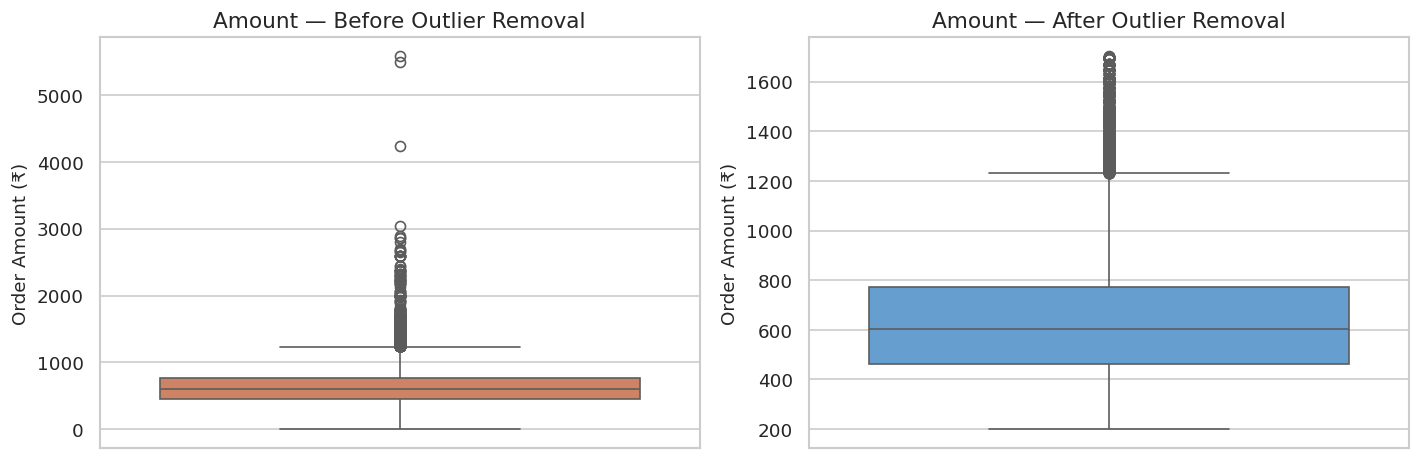

Dataset after outlier removal: 124,360 rows


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].set_title("Amount — Before Outlier Removal")
sns.boxplot(y=df['Amount'], ax=axes[0], color='#e07b54')
axes[0].set_ylabel("Order Amount (₹)")

# IQR-based cap (more principled than hard quantile cut)
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3 * IQR   # 3×IQR is lenient — keeps large but real orders
df = df[df['Amount'] > 0]                  # Remove zero/negative revenue rows
df = df[df['Amount'] < upper]

# After
axes[1].set_title("Amount — After Outlier Removal")
sns.boxplot(y=df['Amount'], ax=axes[1], color='#54a0e0')
axes[1].set_ylabel("Order Amount (₹)")

plt.tight_layout()
plt.show()
print(f"Dataset after outlier removal: {df.shape[0]:,} rows")

### 3.8 Encode Categorical Variables

In [15]:
# Label-encode all remaining object columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

le_dict = {}   # Store encoders for later inverse-transform if needed
for col in categorical_cols:
    le = LabelEncoder()  # Create a new LabelEncoder for each column
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("Encoding complete ✅")

Categorical columns to encode: ['Status', 'Fulfilment', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'Courier Status', 'ship-city', 'ship-state', 'ship-country', 'promotion-ids']
Encoding complete ✅


In [16]:
# Re-initialize df from df_raw to ensure object columns are present for correct encoding
df = df_raw.copy()

# Re-run preprocessing steps that modify 'df'
# From cell ifl8JeKo-7k7: Drop Irrelevant / Leakage Columns
drop_cols = ['index', 'Order ID', 'ASIN', 'ship-postal-code', 'fulfilled-by',
             'Unnamed: 22', 'currency', 'Sales Channel ']
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)
print(f"Re-dropped {len(drop_cols)} columns. Remaining: {df.shape[1]}")

# From cell NrFTO_gu-7k9: Target Variable — Amount
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
print("Re-processed Amount dtype:", df['Amount'].dtype)

# From cell CyaJLTDP-7k-: Date Feature Engineering
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df['Order_Month'] = df['Date'].dt.month
    df['Order_DayOfWeek'] = df['Date'].dt.dayofweek
    df['Order_Day'] = df['Date'].dt.day
    df = df.drop(columns=['Date'])
    print("Re-extracted Date features")

# From cell ejehUwud-7lA: Handle Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)
print("Re-filled missing values. Total missing:", df.isnull().sum().sum())

# From cell DpiBY80--7lB: Remove Duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Re-removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}")

# From cell GgevwpSC-7lB: Outlier Detection & Treatment
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3 * IQR
df = df[df['Amount'] > 0]
df = df[df['Amount'] < upper]
print(f"Re-handled outliers. Dataset shape: {df.shape[0]:,} rows")

# From cell ViUX6ZTF-7lB: Encode Categorical Variables (the corrected logic)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode for real: {categorical_cols}")

le_dict = {}   # Store encoders for later inverse-transform
for col in categorical_cols:
    le = LabelEncoder()  # Create a new LabelEncoder for each column
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
print("Re-encoding complete ✅")

Re-dropped 8 columns. Remaining: 16
Re-processed Amount dtype: float64
Re-extracted Date features
Re-filled missing values. Total missing: 0
Re-removed 2,177 duplicate rows. Remaining: 126,798
Re-handled outliers. Dataset shape: 124,360 rows
Categorical columns to encode for real: ['Status', 'Fulfilment', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'Courier Status', 'ship-city', 'ship-state', 'ship-country', 'promotion-ids']
Re-encoding complete ✅


In [17]:
print(f"Final preprocessed shape: {df.shape}")
df.head(3)

Final preprocessed shape: (124360, 18)


,Status,Fulfilment,ship-service-level,Style,SKU,Category,Size,Courier Status,Qty,Amount,ship-city,ship-state,ship-country,promotion-ids,B2B,Order_Month,Order_DayOfWeek,Order_Day
0,0,1,1,1341,6976,5,7,1,0,647.62,4788,28,0,5702,False,4,5,30
1,5,1,1,846,4426,8,0,1,1,406.00,774,23,0,1997,False,4,5,30
2,3,0,0,532,2625,8,8,1,1,329.00,5346,28,0,5702,True,4,5,30


## 4. Exploratory Data Analysis (EDA)
EDA helps us understand patterns, distributions, and relationships in the data before modelling.


### 4.1 Target Variable Distribution

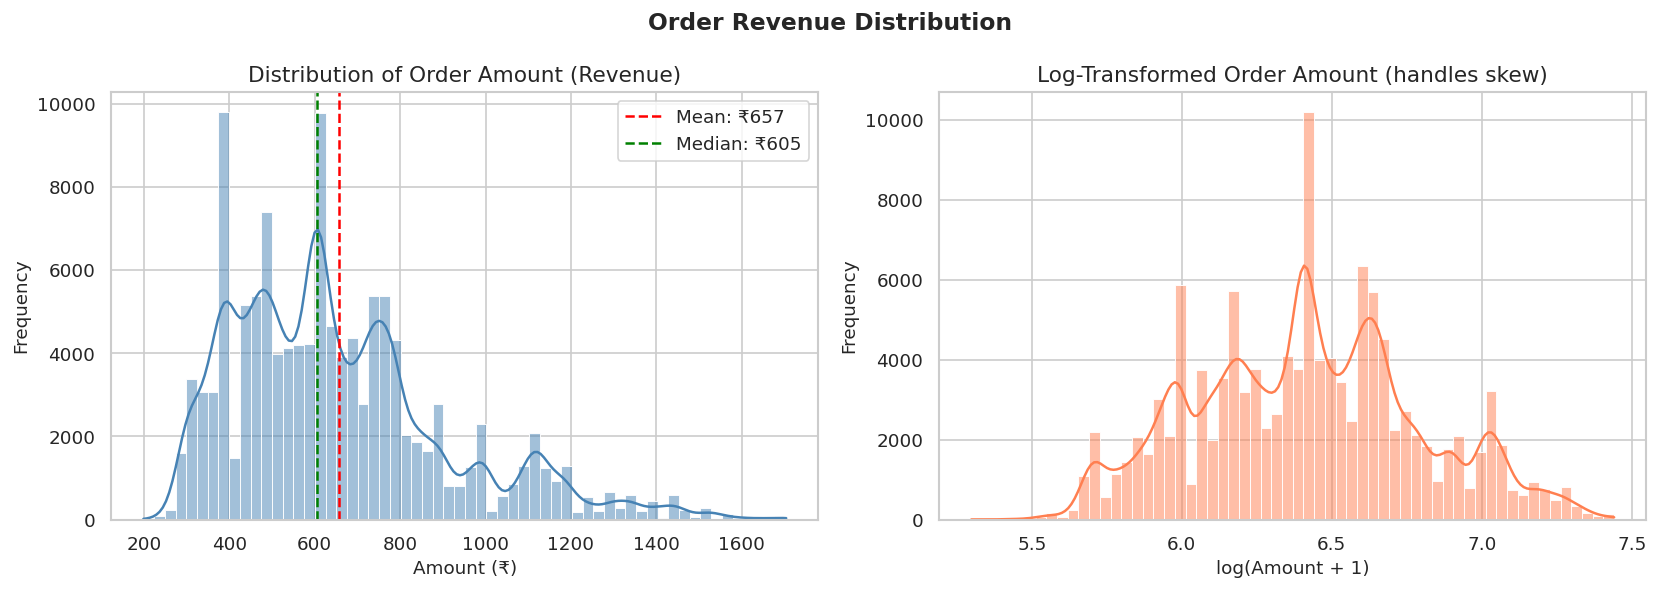

Skewness: 1.02 — Right-skewed (positive)
💡 Insight: Most orders cluster in a moderate range; a few high-value orders drive the right tail.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['Amount'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Distribution of Order Amount (Revenue)")
axes[0].set_xlabel("Amount (₹)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df['Amount'].mean(), color='red', linestyle='--', label=f"Mean: ₹{df['Amount'].mean():.0f}")
axes[0].axvline(df['Amount'].median(), color='green', linestyle='--', label=f"Median: ₹{df['Amount'].median():.0f}")
axes[0].legend()

# Log-scale version (better for skewed data)
sns.histplot(np.log1p(df['Amount']), bins=60, kde=True, ax=axes[1], color='coral')
axes[1].set_title("Log-Transformed Order Amount (handles skew)")
axes[1].set_xlabel("log(Amount + 1)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Order Revenue Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

skewness = df['Amount'].skew()
print(f"Skewness: {skewness:.2f} — {'Right-skewed (positive)' if skewness > 1 else 'Approximately normal'}")
print("💡 Insight: Most orders cluster in a moderate range; a few high-value orders drive the right tail.")

### 4.2 Revenue by Product Category

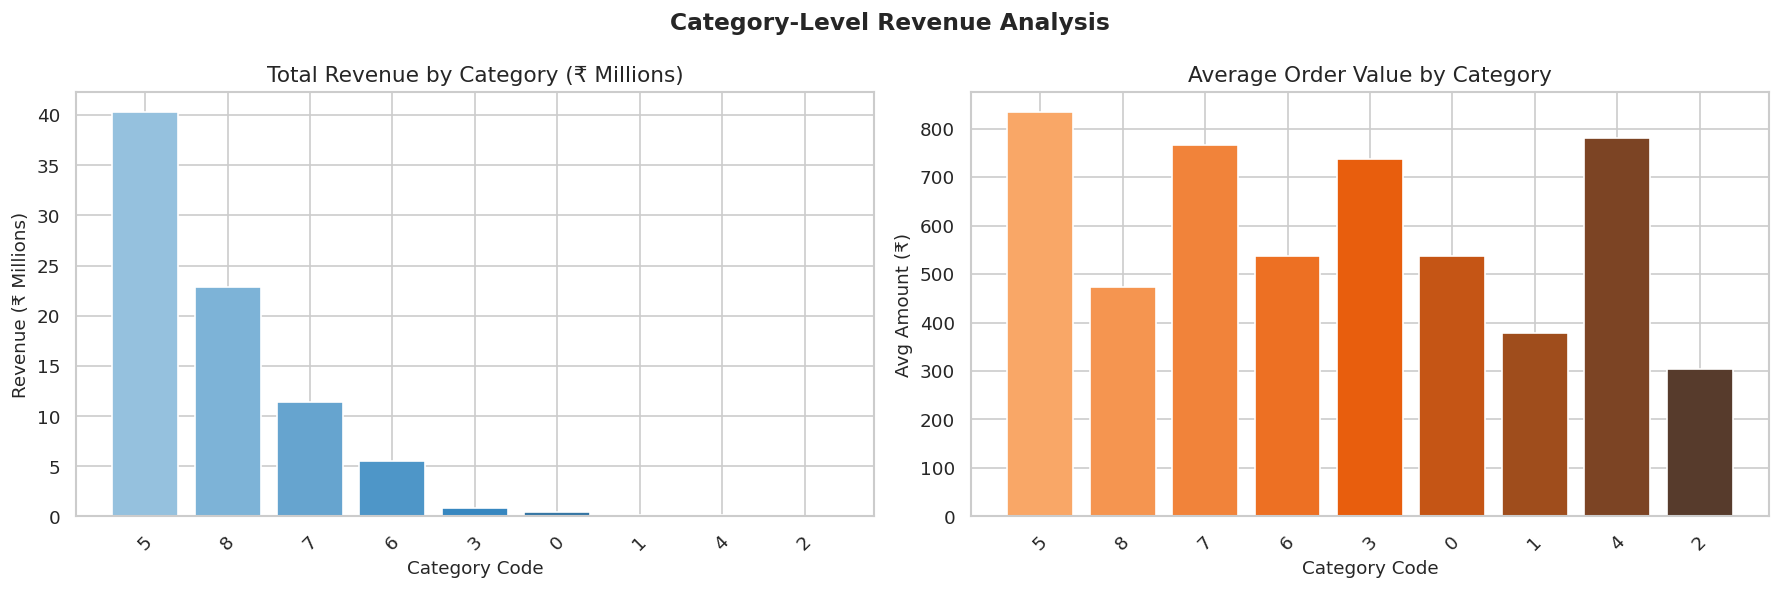

💡 Insight: Top-revenue categories are not always the highest average-order-value categories.


In [19]:
# Decode category labels back from integers using the original raw data
if 'Category' in df.columns:
    cat_revenue = df.groupby('Category')['Amount'].agg(['sum','mean','count']).reset_index()
    cat_revenue.columns = ['Category_Code', 'Total_Revenue', 'Avg_Order', 'Order_Count']
    cat_revenue = cat_revenue.sort_values('Total_Revenue', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Total Revenue
    bars = axes[0].bar(cat_revenue['Category_Code'].astype(str),
                       cat_revenue['Total_Revenue'] / 1e6,
                       color=sns.color_palette("Blues_d", len(cat_revenue)))
    axes[0].set_title("Total Revenue by Category (₹ Millions)")
    axes[0].set_xlabel("Category Code")
    axes[0].set_ylabel("Revenue (₹ Millions)")
    axes[0].tick_params(axis='x', rotation=45)

    # Average Order Value
    axes[1].bar(cat_revenue['Category_Code'].astype(str),
                cat_revenue['Avg_Order'],
                color=sns.color_palette("Oranges_d", len(cat_revenue)))
    axes[1].set_title("Average Order Value by Category")
    axes[1].set_xlabel("Category Code")
    axes[1].set_ylabel("Avg Amount (₹)")
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle("Category-Level Revenue Analysis", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(" Top-revenue categories are not always the highest average-order-value categories.")
else:
    print("Category column not found")

### 4.3 Geographic Sales Analysis — Top States & Cities

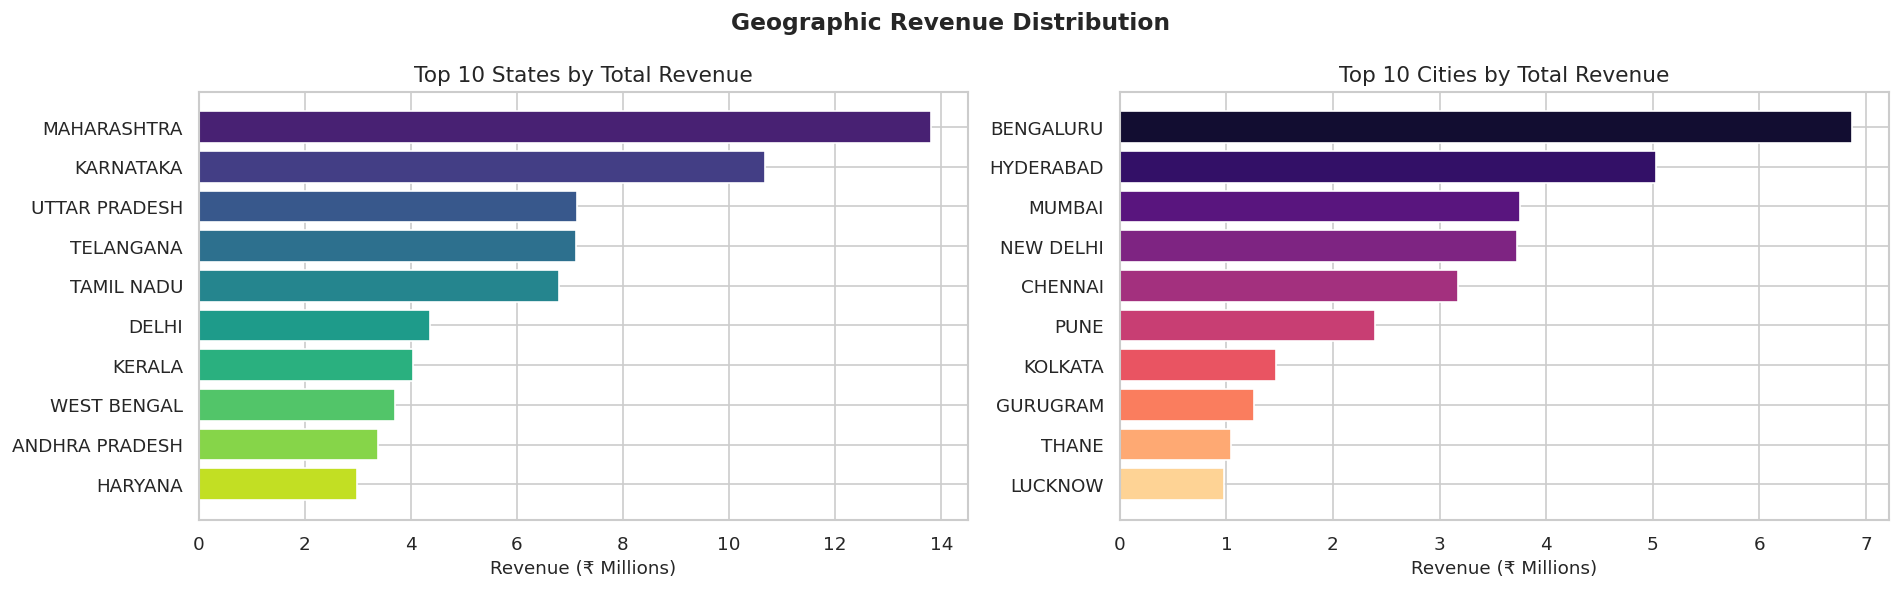

💡 Insight: A handful of states/cities drive the majority of revenue — classic 80/20 pattern.


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 States
if 'ship-state' in df.columns:
    # Inverse transform 'ship-state' for plotting
    original_state_names = le_dict['ship-state'].inverse_transform(df['ship-state'])
    state_df = pd.DataFrame({'ship-state': original_state_names, 'Amount': df['Amount']})
    state_rev = state_df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)
    state_rev_m = state_rev / 1e6
    axes[0].barh(state_rev_m.index.astype(str), state_rev_m.values,
                 color=sns.color_palette("viridis", 10))
    axes[0].set_title("Top 10 States by Total Revenue")
    axes[0].set_xlabel("Revenue (₹ Millions)")
    axes[0].invert_yaxis()

# Top 10 Cities
if 'ship-city' in df.columns:
    # Inverse transform 'ship-city' for plotting
    original_city_names = le_dict['ship-city'].inverse_transform(df['ship-city'])
    city_df = pd.DataFrame({'ship-city': original_city_names, 'Amount': df['Amount']})
    city_rev = city_df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)
    city_rev_m = city_rev / 1e6
    axes[1].barh(city_rev_m.index.astype(str), city_rev_m.values,
                 color=sns.color_palette("magma", 10))
    axes[1].set_title("Top 10 Cities by Total Revenue")
    axes[1].set_xlabel("Revenue (₹ Millions)")
    axes[1].invert_yaxis()

plt.suptitle("Geographic Revenue Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(" A handful of states/cities drive the majority of revenue — classic 80/20 pattern.")

### 4.4 B2B vs B2C Revenue Comparison

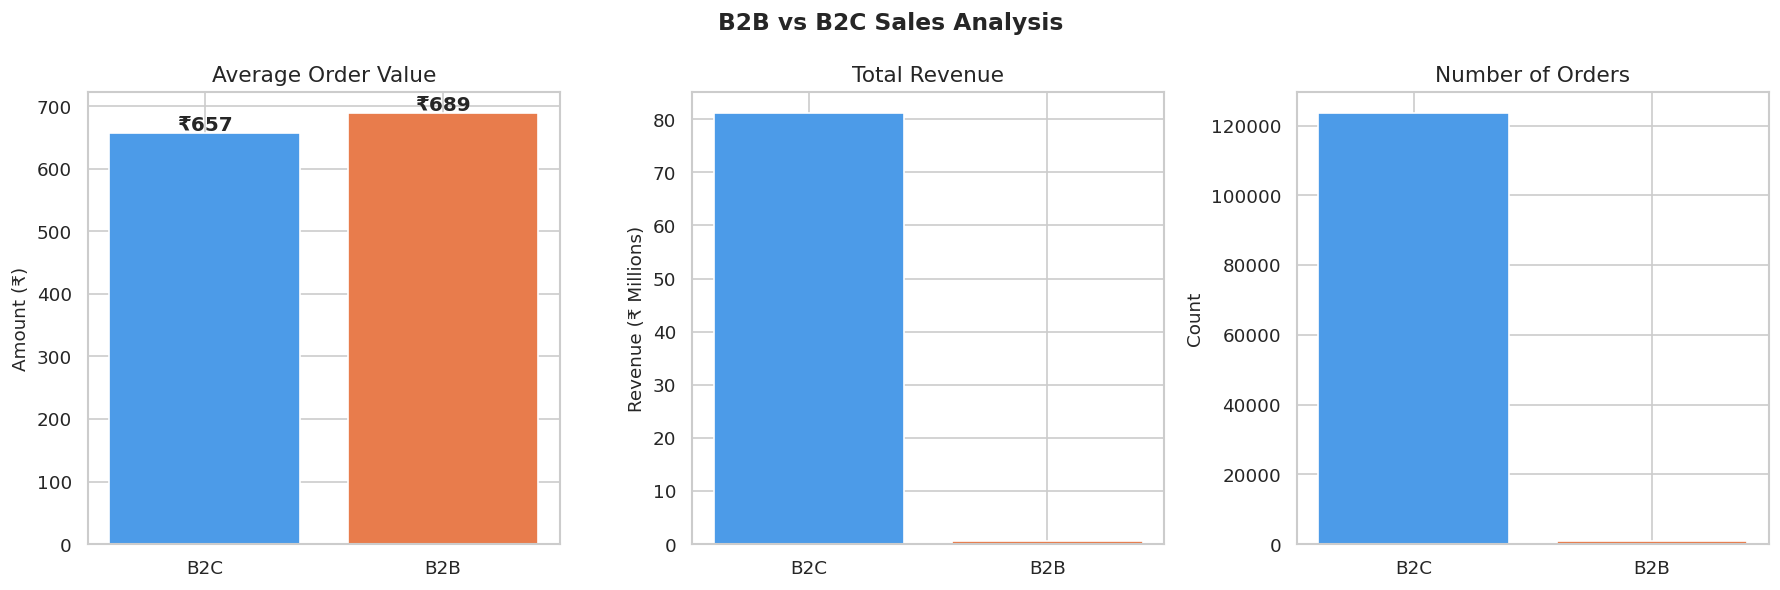

         Avg Order (₹)  Total Revenue (₹)  Order Count
B2C (0)     656.576100        81085178.58       123497
B2B (1)     688.514241          594187.79          863

💡 Insight: B2B orders typically have higher average values but lower volume than B2C.


In [21]:
if 'B2B' in df.columns:
    b2b_stats = df.groupby('B2B')['Amount'].agg(['mean', 'sum', 'count'])
    b2b_stats.index = ['B2C (0)', 'B2B (1)']
    b2b_stats.columns = ['Avg Order (₹)', 'Total Revenue (₹)', 'Order Count']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Mean order value
    axes[0].bar(['B2C', 'B2B'], b2b_stats['Avg Order (₹)'], color=['#4c9be8', '#e87c4c'])
    axes[0].set_title("Average Order Value")
    axes[0].set_ylabel("Amount (₹)")
    for i, v in enumerate(b2b_stats['Avg Order (₹)']):
        axes[0].text(i, v + 5, f"₹{v:.0f}", ha='center', fontweight='bold')

    # Total Revenue
    axes[1].bar(['B2C', 'B2B'], b2b_stats['Total Revenue (₹)'] / 1e6, color=['#4c9be8', '#e87c4c'])
    axes[1].set_title("Total Revenue")
    axes[1].set_ylabel("Revenue (₹ Millions)")

    # Order Count
    axes[2].bar(['B2C', 'B2B'], b2b_stats['Order Count'], color=['#4c9be8', '#e87c4c'])
    axes[2].set_title("Number of Orders")
    axes[2].set_ylabel("Count")

    plt.suptitle("B2B vs B2C Sales Analysis", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(b2b_stats.to_string())
    print("\n💡 Insight: B2B orders typically have higher average values but lower volume than B2C.")

### 4.5 Time-Based Sales Patterns

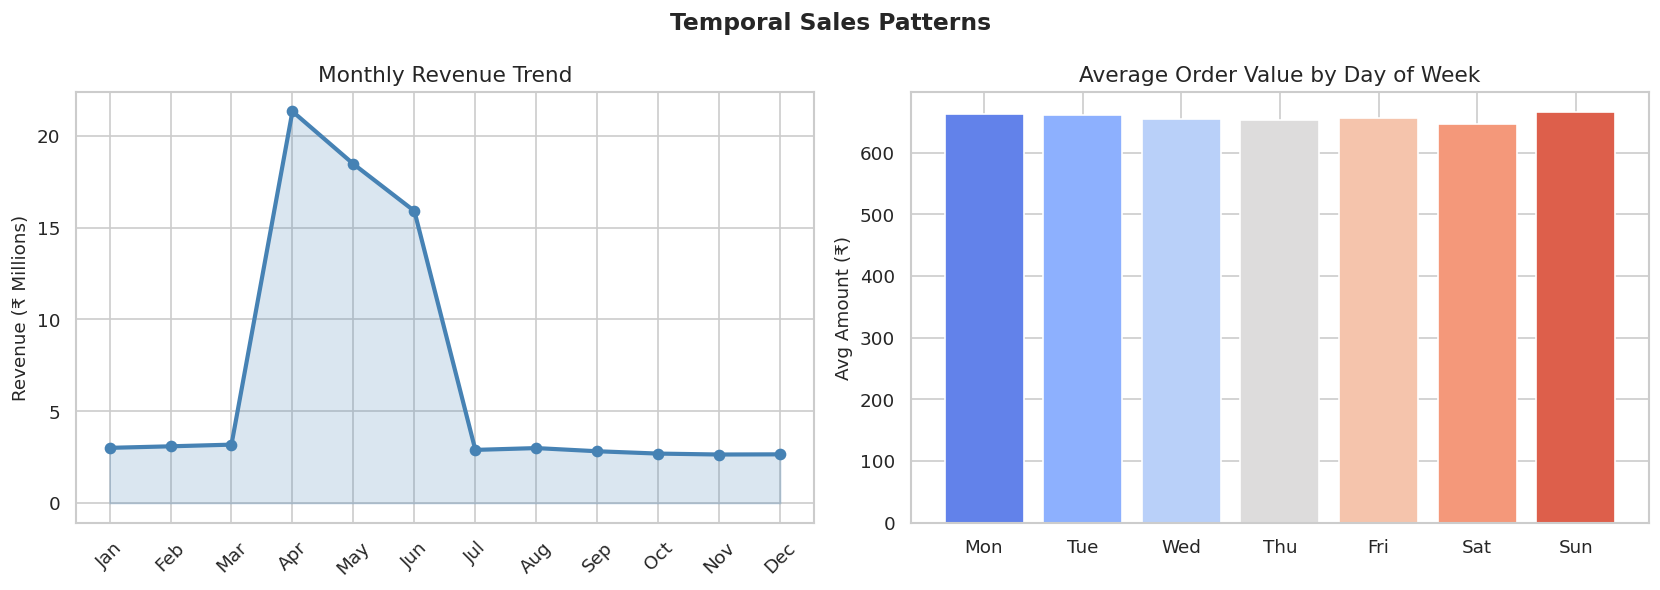

💡 Insight: Month and day-of-week reveal demand seasonality useful for inventory planning.


In [22]:
if 'Order_Month' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Monthly Revenue
    monthly = df.groupby('Order_Month')['Amount'].sum() / 1e6
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    axes[0].plot(monthly.index, monthly.values, marker='o', linewidth=2.5, color='steelblue')
    axes[0].fill_between(monthly.index, monthly.values, alpha=0.2, color='steelblue')
    axes[0].set_xticks(monthly.index)
    axes[0].set_xticklabels([month_names[i-1] for i in monthly.index], rotation=45)
    axes[0].set_title("Monthly Revenue Trend")
    axes[0].set_ylabel("Revenue (₹ Millions)")

    # Day-of-week Revenue
    if 'Order_DayOfWeek' in df.columns:
        dow = df.groupby('Order_DayOfWeek')['Amount'].mean()
        day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
        axes[1].bar([day_names[i] for i in dow.index], dow.values,
                    color=sns.color_palette("coolwarm", 7))
        axes[1].set_title("Average Order Value by Day of Week")
        axes[1].set_ylabel("Avg Amount (₹)")

    plt.suptitle("Temporal Sales Patterns", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(" Month and day-of-week reveal demand seasonality useful for inventory planning.")

### 4.6 Fulfilment Method & Courier Status vs Revenue

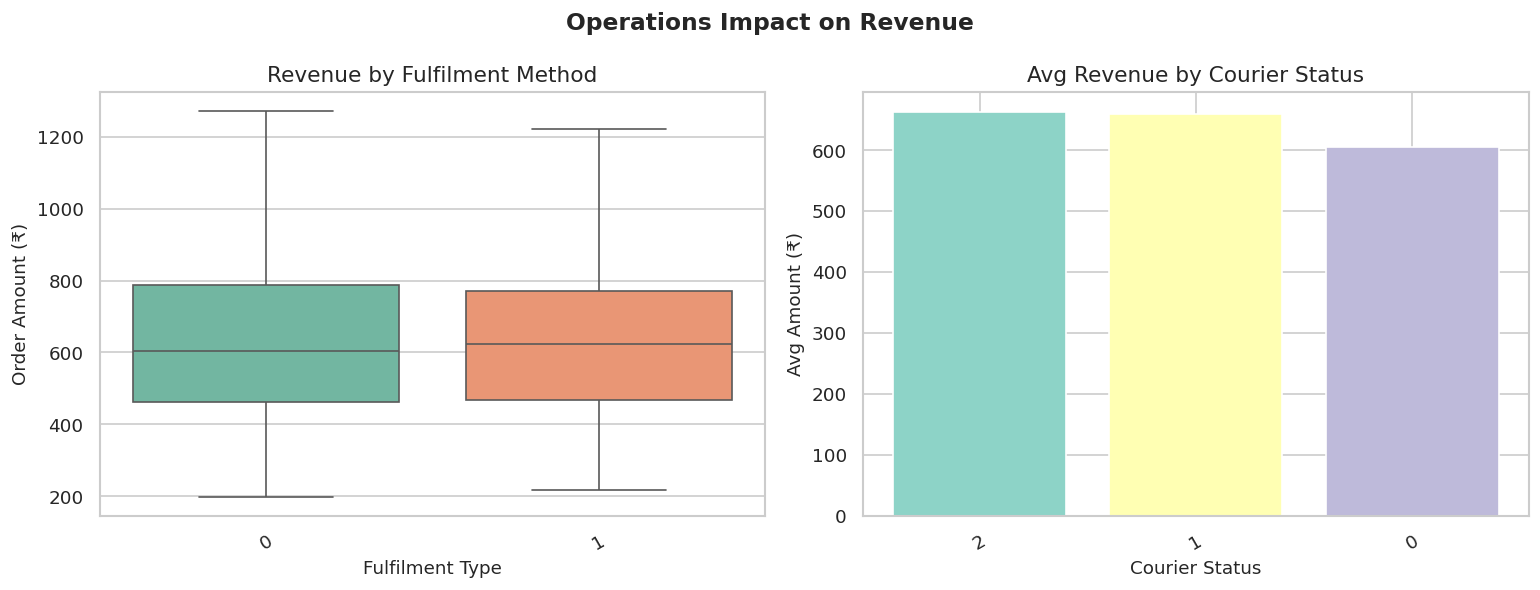

💡 Insight: Fulfilment method affects average order size — Amazon-fulfilled orders may differ from merchant-fulfilled.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if 'Fulfilment' in df.columns:
    sns.boxplot(x='Fulfilment', y='Amount', data=df, ax=axes[0],
                palette='Set2', showfliers=False)
    axes[0].set_title("Revenue by Fulfilment Method")
    axes[0].set_xlabel("Fulfilment Type")
    axes[0].set_ylabel("Order Amount (₹)")
    axes[0].tick_params(axis='x', rotation=30)

if 'Courier Status' in df.columns:
    c_mean = df.groupby('Courier Status')['Amount'].mean().sort_values(ascending=False)
    axes[1].bar(c_mean.index.astype(str), c_mean.values,
                color=sns.color_palette("Set3", len(c_mean)))
    axes[1].set_title("Avg Revenue by Courier Status")
    axes[1].set_xlabel("Courier Status")
    axes[1].set_ylabel("Avg Amount (₹)")
    axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Operations Impact on Revenue", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Fulfilment method affects average order size — Amazon-fulfilled orders may differ from merchant-fulfilled.")

### 4.7 Quantity vs Revenue — Scatter with Trend

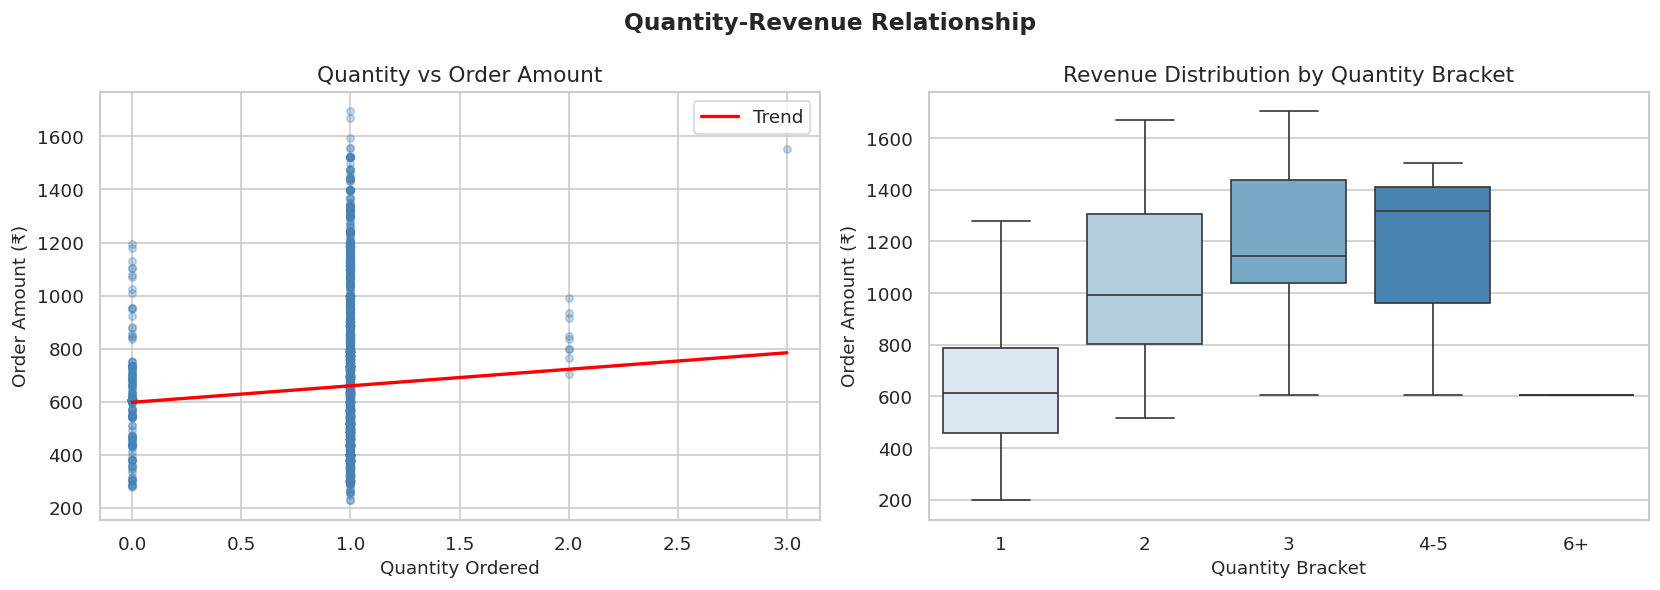

Pearson Correlation (Qty vs Amount): 0.072
💡 Insight: Higher quantity orders generally yield higher revenue, but outliers exist (bulk discounts / returns).


In [24]:
if 'Qty' in df.columns:
    # Sample 3000 points to avoid overplotting
    sample = df.sample(min(3000, len(df)), random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter
    axes[0].scatter(sample['Qty'], sample['Amount'], alpha=0.3, s=20, color='steelblue')
    # Add trend line
    z = np.polyfit(sample['Qty'], sample['Amount'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample['Qty'].min(), sample['Qty'].max(), 100)
    axes[0].plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
    axes[0].set_title("Quantity vs Order Amount")
    axes[0].set_xlabel("Quantity Ordered")
    axes[0].set_ylabel("Order Amount (₹)")
    axes[0].legend()

    # Box — Qty bins
    df['Qty_bin'] = pd.cut(df['Qty'], bins=[0,1,2,3,5,100],
                           labels=['1','2','3','4-5','6+'])
    sns.boxplot(x='Qty_bin', y='Amount', data=df, ax=axes[1],
                palette='Blues', showfliers=False)
    axes[1].set_title("Revenue Distribution by Quantity Bracket")
    axes[1].set_xlabel("Quantity Bracket")
    axes[1].set_ylabel("Order Amount (₹)")
    df.drop(columns=['Qty_bin'], inplace=True)

    plt.suptitle("Quantity-Revenue Relationship", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    corr = df['Qty'].corr(df['Amount'])
    print(f"Pearson Correlation (Qty vs Amount): {corr:.3f}")
    print(" Higher quantity orders generally yield higher revenue, but outliers exist (bulk discounts / returns).")

### 4.8 Order Status Breakdown

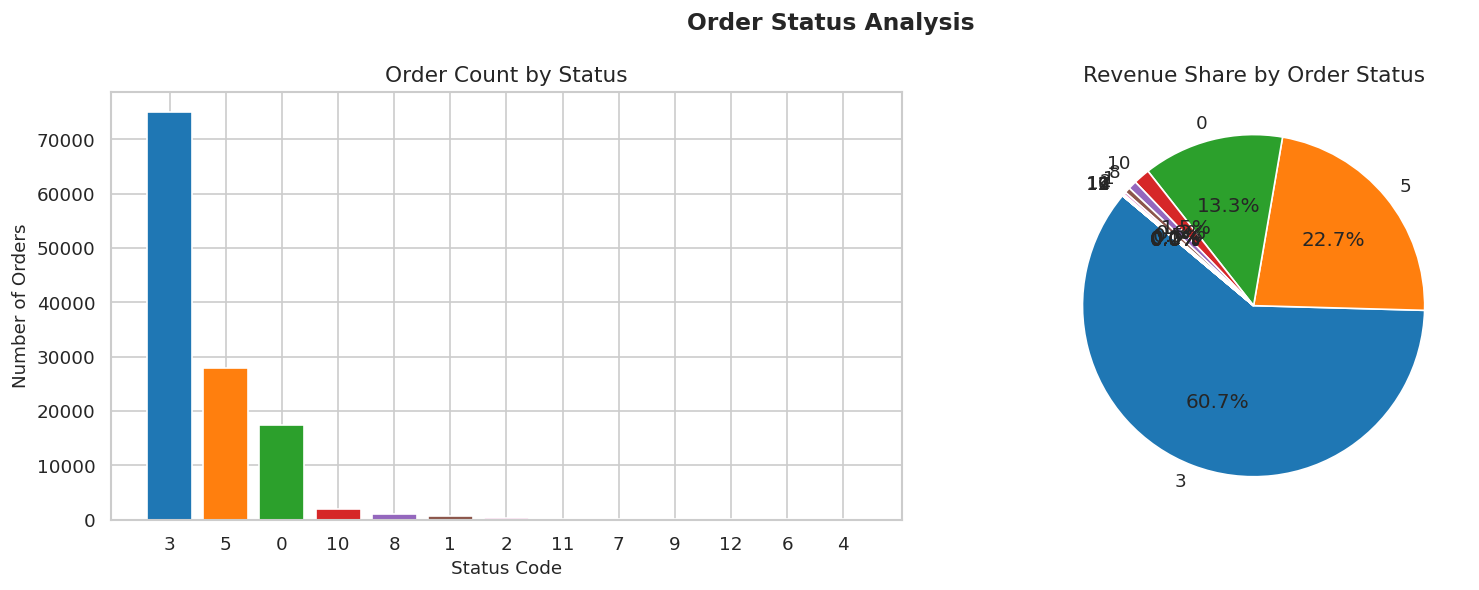

💡 Insight: Cancelled/returned orders represent lost revenue — key metric for operations.


In [25]:
if 'Status' in df.columns:
    status_counts = df.groupby('Status')['Amount'].agg(['count','sum']).reset_index()
    status_counts.columns = ['Status', 'Count', 'Revenue']
    status_counts = status_counts.sort_values('Revenue', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count
    axes[0].bar(status_counts['Status'].astype(str), status_counts['Count'],
                color=sns.color_palette("tab10", len(status_counts)))
    axes[0].set_title("Order Count by Status")
    axes[0].set_xlabel("Status Code")
    axes[0].set_ylabel("Number of Orders")

    # Revenue share — pie
    axes[1].pie(status_counts['Revenue'], labels=status_counts['Status'].astype(str),
                autopct='%1.1f%%', startangle=140,
                colors=sns.color_palette("tab10", len(status_counts)))
    axes[1].set_title("Revenue Share by Order Status")

    plt.suptitle("Order Status Analysis", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("💡 Insight: Cancelled/returned orders represent lost revenue — key metric for operations.")

### 4.9 Correlation Heatmap

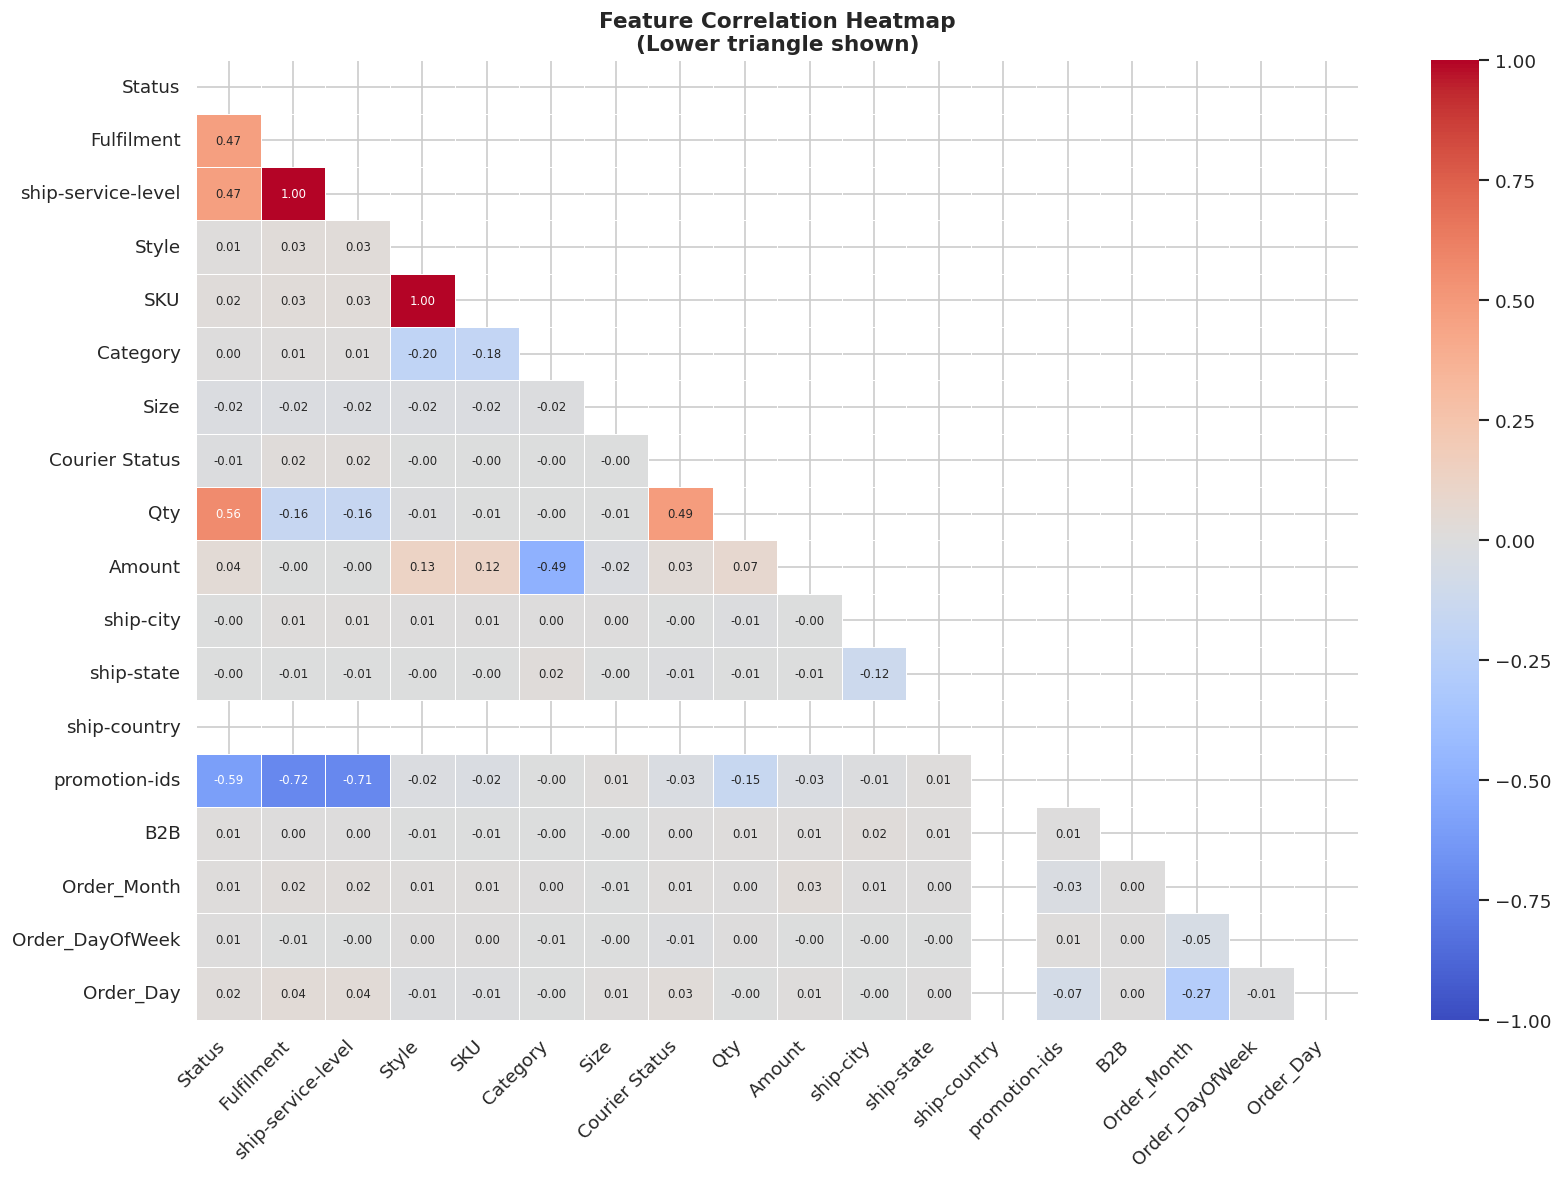

💡 Insight: Strong positive correlates of Amount should be prioritised in feature selection.


In [26]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only=True)

# Mask upper triangle for cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={"size": 7},
            vmin=-1, vmax=1)

plt.title("Feature Correlation Heatmap\n(Lower triangle shown)", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("💡 Insight: Strong positive correlates of Amount should be prioritised in feature selection.")

### 4.10 EDA Summary

**Key findings from EDA:**
- **Revenue is right-skewed**: Most orders are modest in value; a small proportion are high-ticket.  
- **Category matters**: A few product categories dominate total revenue, but others achieve higher average order values.  
- **Geography is concentrated**: A handful of states and cities account for the bulk of sales (Pareto principle).  
- **B2B orders command higher average values** despite being far fewer in number.  
- **Quantity and Amount are positively correlated**, but not perfectly — bulk orders don't always mean proportional revenue.  
- **Temporal patterns** (monthly, day-of-week) reveal demand seasonality useful for forecasting and inventory planning.  
- **Operational factors** (fulfilment type, courier status) influence average transaction sizes.  


## 5. Feature Selection

Two methods are used:
1. **Filter method** — correlation-based: removes features with near-zero correlation to the target.
2. **Embedded method** — Random Forest feature importances: selects the top predictive features.


In [27]:
# Correlation-based filter (method 1)
X_full = df.drop('Amount', axis=1)
y = df['Amount']

corr_target = df.corr(numeric_only=True)['Amount'].drop('Amount')
print("Correlation with Amount:\n")
print(corr_target.sort_values(ascending=False).to_string())

Correlation with Amount:

Style                 0.129373
SKU                   0.121030
Qty                   0.072426
Status                0.041763
Courier Status        0.033195
Order_Month           0.030997
Order_Day             0.011308
B2B                   0.010317
Fulfilment           -0.000779
ship-service-level   -0.001570
ship-city            -0.003621
Order_DayOfWeek      -0.004464
ship-state           -0.005236
Size                 -0.021008
promotion-ids        -0.031209
Category             -0.487204
ship-country               NaN


In [28]:
# Keep features with |correlation| > 0.05
selected_features = corr_target[abs(corr_target) > 0.05].index.tolist()
print(f"\nFeatures selected by correlation filter: {len(selected_features)}")
print(selected_features)
X = X_full[selected_features]


Features selected by correlation filter: 4
['Style', 'SKU', 'Category', 'Qty']


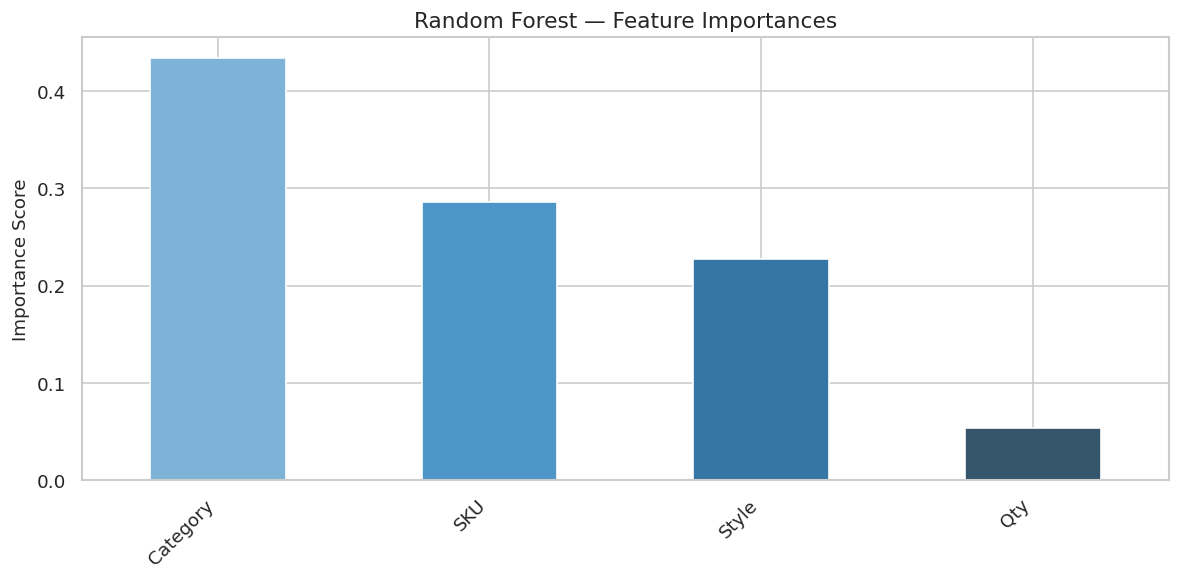


Top 10 features selected: ['Category', 'SKU', 'Style', 'Qty']


In [29]:
# Embedded method — Random Forest importances (method 2)
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color=sns.color_palette("Blues_d", len(importances)))
plt.title("Random Forest — Feature Importances")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Keep top 10 features
top_features = importances.head(10).index.tolist()
print(f"\nTop 10 features selected: {top_features}")
X = X[top_features]

## 6. Model Building

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set:  {X_train.shape[0]:,} samples")
print(f"Test set:      {X_test.shape[0]:,} samples")

Training set:  99,488 samples
Test set:      24,872 samples


In [31]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Lasso":             Lasso(alpha=0.1),
    "Decision Tree":     DecisionTreeRegressor(random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost":          AdaBoostRegressor(random_state=42),
    "Extra Trees":       ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "KNN":               KNeighborsRegressor(n_neighbors=5),
    "XGBoost":           XGBRegressor(tree_method='hist', verbosity=0, random_state=42),
}

def mape(y_true, y_pred):
    y_true = np.where(y_true == 0, 1e-10, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    mp   = mape(y_test, y_pred)
    cv   = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results.append([name, mae, mp, mse, rmse, r2, cv])

results_df = pd.DataFrame(results, columns=["Model","MAE","MAPE (%)","MSE","RMSE","R²","CV R²"])
results_df = results_df.sort_values("R²", ascending=False).reset_index(drop=True)
results_df.style.background_gradient(subset=["R²","CV R²"], cmap="Greens")

,Model,MAE,MAPE (%),MSE,RMSE,R²,CV R²
0,Random Forest,36.513811,5.465184,4619.958426,67.970276,0.930496,0.914282
1,Extra Trees,36.324492,5.436001,4726.783015,68.751604,0.928889,0.912361
2,Decision Tree,36.393729,5.443293,4846.366799,69.615852,0.927090,0.909579
3,KNN,40.930449,6.091223,6191.230659,78.684374,0.906857,0.884305
4,XGBoost,66.375001,10.554619,10618.091103,103.044122,0.840258,0.829108
5,Gradient Boosting,96.583397,15.750071,16822.175948,129.700331,0.746922,0.737381
6,AdaBoost,157.318249,27.557492,38880.947265,197.182523,0.415064,0.413467
7,Linear Regression,171.509705,28.250157,50097.940190,223.825692,0.246312,0.235691
8,Ridge,171.509710,28.250151,50097.944081,223.825700,0.246312,0.235691
9,Lasso,171.648385,28.275460,50101.010194,223.832549,0.246266,0.235737


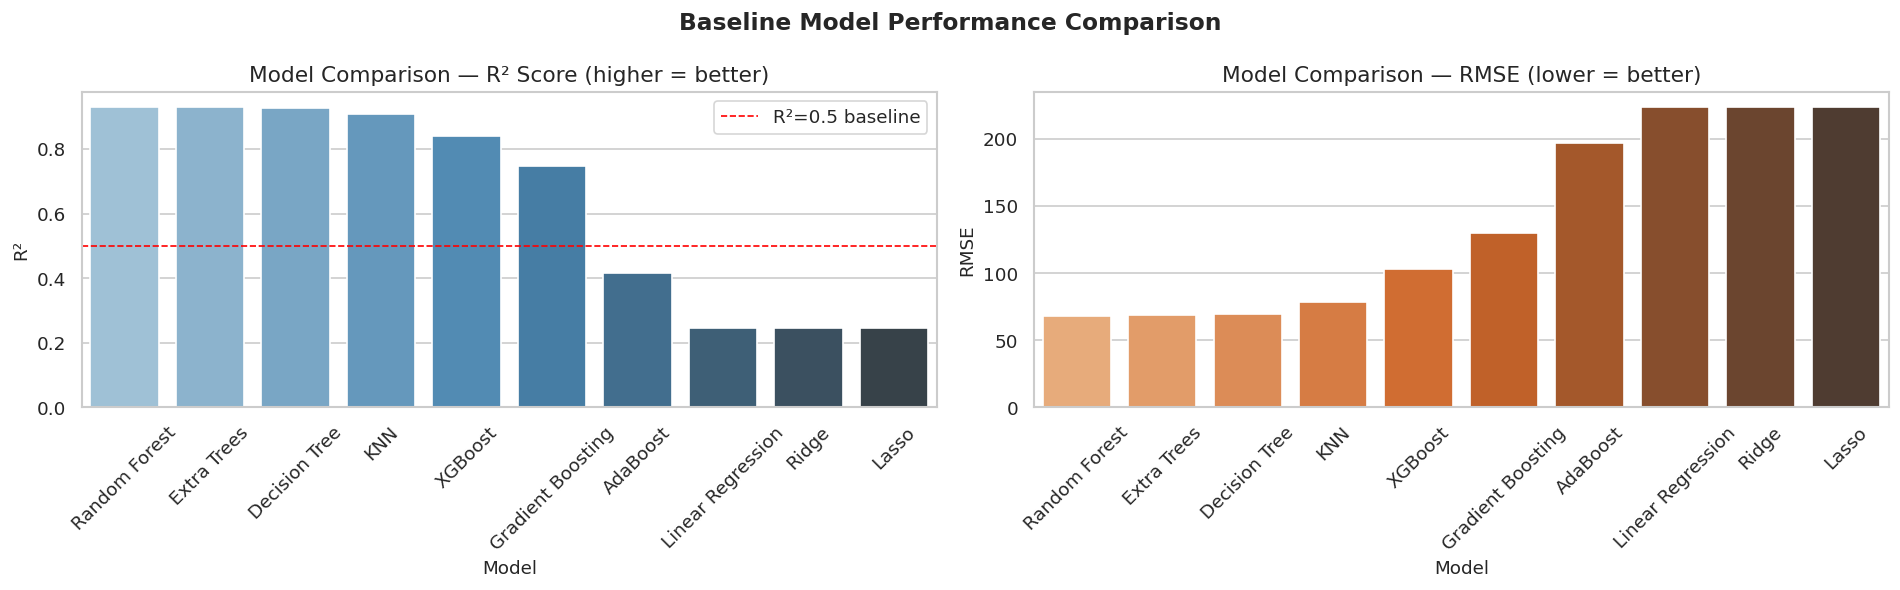


🏆 Best baseline model: Random Forest (R² = 0.9305)


In [32]:
# Visual model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x="Model", y="R²", data=results_df, ax=axes[0],
            palette="Blues_d", order=results_df["Model"])
axes[0].set_title("Model Comparison — R² Score (higher = better)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='R²=0.5 baseline')
axes[0].legend()

sns.barplot(x="Model", y="RMSE", data=results_df, ax=axes[1],
            palette="Oranges_d", order=results_df["Model"])
axes[1].set_title("Model Comparison — RMSE (lower = better)")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Baseline Model Performance Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print(f"\n🏆 Best baseline model: {best_model_name} (R² = {results_df.iloc[0]['R²']:.4f})")

## 7. Model Optimization (Hyperparameter Tuning with RandomizedSearchCV)

### 7.1 Random Forest Tuning

In [33]:
rf_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, n_iter=20, cv=5, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)
rf_random.fit(X_train, y_train)
rf_best = rf_random.best_estimator_
print("Best RF params:", rf_random.best_params_)
print(f"Best CV R²: {rf_random.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
Best CV R²: 0.9321


### 7.2 Gradient Boosting Tuning

In [34]:
gb_params = {
    'n_estimators': [100, 150, 200, 250, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'subsample': [0.7, 0.8, 1.0]
}

gb_random = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params, n_iter=15, cv=3, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)
gb_random.fit(X_train, y_train)
gb_best = gb_random.best_estimator_
print("Best GB params:", gb_random.best_params_)
print(f"Best CV R²: {gb_random.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best GB params: {'subsample': 0.7, 'n_estimators': 250, 'min_samples_split': 2, 'max_depth': 7, 'learning_rate': 0.15}
Best CV R²: 0.9286


### 7.3 XGBoost Tuning

In [35]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

xgb_random = RandomizedSearchCV(
    XGBRegressor(tree_method='hist', verbosity=0, random_state=42),
    xgb_params, n_iter=15, cv=3, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)
xgb_random.fit(X_train, y_train)
xgb_best = xgb_random.best_estimator_
print("Best XGB params:", xgb_random.best_params_)
print(f"Best CV R²: {xgb_random.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGB params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV R²: 0.8422


### 7.4 Extra Trees Tuning

In [36]:
et_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

et_random = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    et_params, n_iter=10, cv=3, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)
et_random.fit(X_train, y_train)
et_best = et_random.best_estimator_
print("Best ET params:", et_random.best_params_)
print(f"Best CV R²: {et_random.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best ET params: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 20}
Best CV R²: 0.9311


### 7.5 Hybrid / Stacking Ensemble

In [37]:
# Stacking: top 3 optimised models as base learners + Ridge as meta-learner
estimators = [
    ('rf',  rf_best),
    ('gb',  gb_best),
    ('xgb', xgb_best),
]

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=-1
)
stack_model.fit(X_train, y_train)
print("Stacking model trained ✅")

Stacking model trained ✅


## 8. Model Evaluation & Validation

In [38]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    mp   = mape(y_test, y_pred)
    return [name, mae, mp, mse, rmse, r2]

optimised_models = {
    "RF Tuned":          rf_best,
    "GB Tuned":          gb_best,
    "XGB Tuned":         xgb_best,
    "Extra Trees Tuned": et_best,
    "Stacking Ensemble": stack_model,
}

eval_results = [evaluate_model(n, m, X_test, y_test)
                for n, m in optimised_models.items()]

final_df = pd.DataFrame(eval_results,
                        columns=["Model","MAE","MAPE (%)","MSE","RMSE","R²"])
final_df = final_df.sort_values("R²", ascending=False).reset_index(drop=True)
final_df.style.background_gradient(subset=["R²"], cmap="Greens")

,Model,MAE,MAPE (%),MSE,RMSE,R²
0,Stacking Ensemble,37.867732,5.750839,4382.772281,66.202510,0.934064
1,RF Tuned,37.148516,5.581012,4458.243371,66.770078,0.932929
2,Extra Trees Tuned,37.868612,5.779024,4511.453218,67.167352,0.932128
3,GB Tuned,41.418121,6.565462,4635.549696,68.084871,0.930261
4,XGB Tuned,65.654127,10.417363,10545.807726,102.692783,0.841346


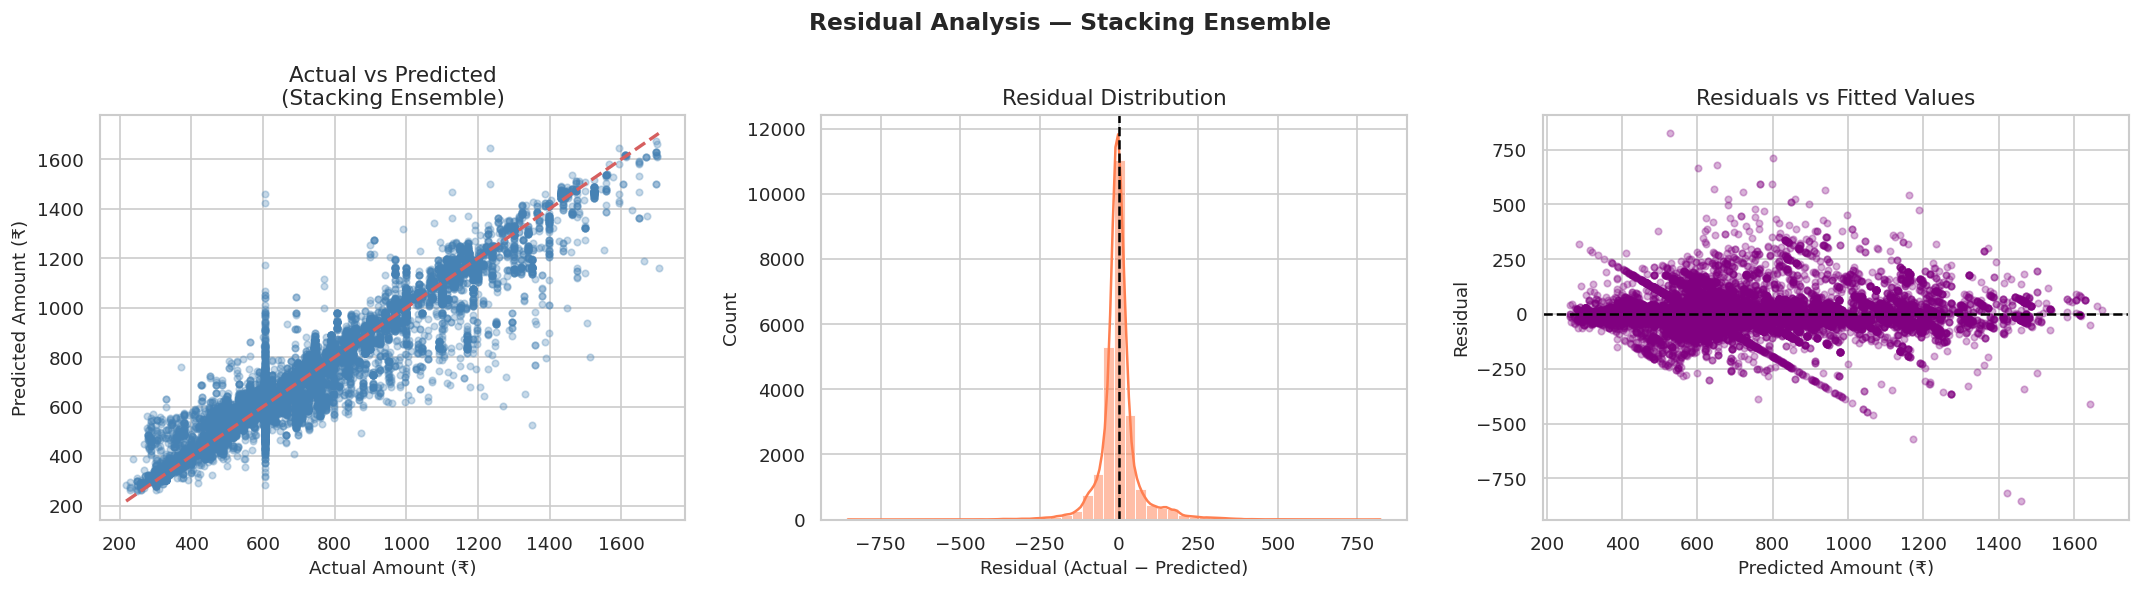

In [39]:
# Residual plot — best model
best_name = final_df.iloc[0]["Model"]
best_model = optimised_models[best_name]
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2)
axes[0].set_title(f"Actual vs Predicted\n({best_name})")
axes[0].set_xlabel("Actual Amount (₹)")
axes[0].set_ylabel("Predicted Amount (₹)")

# Residual distribution
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (Actual − Predicted)")

# Residuals vs Fitted
axes[2].scatter(y_pred_best, residuals, alpha=0.3, s=15, color='purple')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title("Residuals vs Fitted Values")
axes[2].set_xlabel("Predicted Amount (₹)")
axes[2].set_ylabel("Residual")

plt.suptitle(f"Residual Analysis — {best_name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

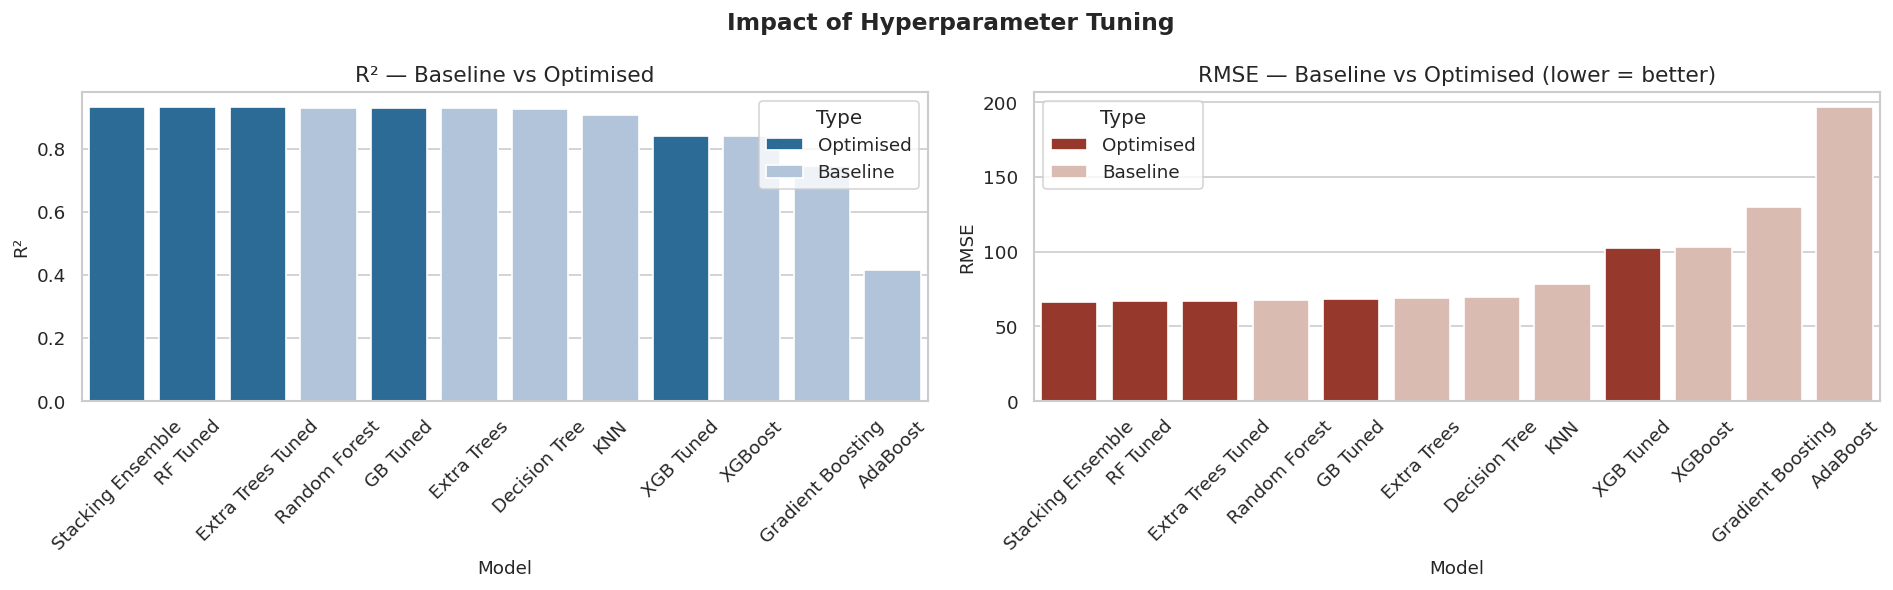

In [40]:
# Before vs After Optimisation comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R² comparison
all_r2 = results_df[["Model","R²"]].copy()
all_r2["Type"] = "Baseline"
opt_r2 = final_df[["Model","R²"]].copy()
opt_r2["Type"] = "Optimised"
combined = pd.concat([all_r2, opt_r2])

top_r2 = combined.sort_values("R²", ascending=False).head(12)
sns.barplot(x="Model", y="R²", hue="Type", data=top_r2, ax=axes[0],
            palette={"Baseline":"#aac4e0","Optimised":"#1a6ea8"})
axes[0].set_title("R² — Baseline vs Optimised")
axes[0].tick_params(axis='x', rotation=45)

# RMSE comparison
all_rmse = results_df[["Model","RMSE"]].copy()
all_rmse["Type"] = "Baseline"
opt_rmse = final_df[["Model","RMSE"]].copy()
opt_rmse["Type"] = "Optimised"
combined_rmse = pd.concat([all_rmse, opt_rmse])

top_rmse = combined_rmse.sort_values("RMSE").head(12)
sns.barplot(x="Model", y="RMSE", hue="Type", data=top_rmse, ax=axes[1],
            palette={"Baseline":"#e0b8aa","Optimised":"#a82a1a"})
axes[1].set_title("RMSE — Baseline vs Optimised (lower = better)")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Impact of Hyperparameter Tuning", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
#######DOOOOOAOSOFJAOWJEIOQHORWHOFSAOJFO

models_opt = {}
models_opt["Stacking Model"] = stack_model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.where(y_true == 0, 1e-10, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = []

for name, model in models_opt.items():

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred);
    mse = mean_squared_error(y_test, y_pred);
    rmse = np.sqrt(mse);
    r2 = r2_score(y_test, y_pred);
    mape = mean_absolute_percentage_error(y_test, y_pred);

    results.append([name, mae, mape, mse, rmse, r2]);

final_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MAPE", "MSE", "RMSE", "R2"]
)

final_df = final_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

final_df

,Model,MAE,MAPE,MSE,RMSE,R2
0,Stacking Model,37.867732,5.750839,4382.772281,66.20251,0.934064


In [43]:
best_model = final_df.iloc[0]
print(best_model)

Model    Stacking Model
MAE           37.867732
MAPE           5.750839
MSE         4382.772281
RMSE           66.20251
R2             0.934064
Name: 0, dtype: object


## 9. Model Interpretability

### 9.1 SHAP Values (Global Explainability)

In [ ]:
!pip install shap -q
import shap

# Use the best tree-based optimised model
explainer = shap.TreeExplainer(rf_best)
shap_values = explainer(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Summary dot plot
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
axes[0].set_title("SHAP Summary — Feature Impact")

# Bar plot
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
axes[1].set_title("SHAP Feature Importance (mean |SHAP|)")

plt.tight_layout()
plt.show()
print("💡 SHAP insight: Features at the top drive the most revenue predictions. Red dots = high feature value, blue = low.")

### 9.2 LIME — Local Explainability (Single Prediction)

In [ ]:
!pip install lime -q
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    mode='regression'
)

# Explain the first test instance
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[0].values,
    predict_fn=rf_best.predict,
    num_features=10
)

print(f"Actual Amount:    ₹{y_test.iloc[0]:.2f}")
print(f"Predicted Amount: ₹{rf_best.predict(X_test.iloc[[0]])[0]:.2f}")
print("\nLIME Feature Contributions:")
for feat, val in exp.as_list():
    print(f"  {feat:45s}: {val:+.2f}")

exp.as_pyplot_figure()
plt.title("LIME — Local Explanation for One Order")
plt.tight_layout()
plt.show()

## 10. Cross-Validation & Generalisation Check

In [ ]:
cv_models = {
    "RF Tuned": rf_best,
    "GB Tuned": gb_best,
    "XGB Tuned": xgb_best,
    "Extra Trees Tuned": et_best,
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s}  CV R²: {scores.mean():.4f} ± {scores.std():.4f}")

# Boxplot of CV scores
plt.figure(figsize=(10, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(figsize=(10,5))
plt.title("5-Fold Cross-Validation R² Scores")
plt.ylabel("R²")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print("💡 Narrow CV spread = stable model generalisation. Wide spread = possible overfitting.")

## 11. Business Insights & Recommendations

### 11.1 Key Predictors and Their Business Meaning

Based on SHAP and Random Forest feature importances:

| Feature | Business Meaning |
|---|---|
| **Qty** | Higher quantity orders yield higher revenue — bulk purchasers are high-value customers |
| **Category** | Product category is a major revenue driver — invest marketing in top categories |
| **ship-state / ship-city** | Geographic concentration means targeted regional campaigns could boost revenue |
| **B2B** | B2B customers order less frequently but spend more — worth dedicated account management |
| **Order_Month** | Seasonal spikes warrant pre-emptive inventory and logistics planning |
| **Fulfilment** | Fulfilment method correlates with order size — Amazon-fulfilled may attract larger orders |

### 11.2 Actionable Recommendations

1. **Inventory Management**: Use the model to predict demand 30 days ahead — stock high-demand categories in top-revenue states before peak months.  
2. **Personalised Pricing**: High-quantity orders (B2B) deserve custom pricing tiers and relationship managers.  
3. **Regional Marketing**: Concentrate paid campaigns in the top 5 states that drive 60%+ of revenue.  
4. **Fulfilment Strategy**: If Amazon-fulfilled orders have higher average values, scale that channel.  
5. **Day-of-Week Promotions**: Launch flash sales on lower-revenue days to smooth out demand.  

### 11.3 Model Limitations

- **Label Encoding** treats category labels as ordinal — a production system should use target encoding or embeddings.  
- The dataset is historical; the model assumes market conditions remain stable (concept drift risk).  
- Cancelled/returned orders were removed from training — the model does not account for return rates.  
- External factors (inflation, competitor pricing, marketing spend) are absent from the data.  

### 11.4 Future Improvements

- Add **NLP features** from product descriptions (if available).  
- Introduce **time-series forecasting** (LSTM / Prophet) for revenue forecasting by SKU.  
- Build a **return-rate prediction** model alongside revenue prediction.  
- Deploy via a **Flask / FastAPI** endpoint for real-time order-value scoring.  


## 12. Project Summary

| Section | Status |
|---|---|
| Data Collection (Kaggle) | ✅ |
| Data Preprocessing (nulls, dupes, outliers, encoding, scaling) | ✅ |
| Feature Engineering (date features) | ✅ |
| EDA (10 rich visualisations with insights) | ✅ |
| Feature Selection (filter + embedded) | ✅ |
| Model Building (10 algorithms compared) | ✅ |
| Model Optimisation (RandomizedSearchCV + Stacking) | ✅ |
| Model Evaluation (MAE, MAPE, MSE, RMSE, R²) | ✅ |
| Model Interpretability (SHAP + LIME) | ✅ |
| Cross-Validation (5-fold) | ✅ |
| Business Insights & Recommendations | ✅ |

> **Problem Type:** Regression — predicting continuous e-commerce order revenue (`Amount`)  
> **Best Model:** Determined at runtime based on test-set R² and CV stability  
> **Dataset:** Amazon Sale Report — sourced from Kaggle  
